# 3D Keypoint Social Interaction Analysis

**Author:** Mir Qi  
**Date:** October 2024  
**Purpose:** Analyze 3D keypoint tracking data from s-DANNCE for multi-animal social behavior experiments. 

## Overview

This notebook demonstrates analysis of 3D pose tracking data merged/aligned with calcium imaging (miniscope) recordings. The pipeline includes:

1. **Data Loading**: Merge s-DANNCE predictions with miniscope and COM data
2. **Distance Analysis**: Compute inter-animal distances and proximity events
3. **Motion Analysis**: Calculate velocities, speeds, and approach behaviors
4. **Visualization**: Plot skeletons, trajectories, and interaction heatmaps
5. **Event Detection**: Identify social interaction incidents and approach sequences

---

## Setup & Imports

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add project root to path
sys.path.append(os.path.abspath('../../..'))

# Import data loading utilities
from utlis.sync_utlis.general_loader import load_flat_with_frame_map, merge_pred_with_miniscope
from utlis.sync_utlis.general_loader_viz import plot_two_coms_from_pred_df

# Import our analysis functions
from keypoint_3d_analysis import (
    compute_com_distance,
    compute_motion_direction,
    detect_approaches,
    get_proximity_rows_by_com,
    point_distance,
    snout_to,
    plot_skeleton_frames,
    KP, MOUSE22_EDGES
)

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

print("✓ Imports complete")

✓ Imports complete


---
## 1. Load & Merge Data

Load DANNCE predictions and merge with miniscope calcium imaging data.

In [3]:
# Configuration
OCT3V1_BASE = "/data/big_rim/rsync_dcc_sum/Oct3V1"
REC_PATH = os.path.join(
    OCT3V1_BASE,
    "2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30"
)

# Miniscope analysis parameters
NC_KEY = 'wnd1500_stp700_max25_diff3.5_pnr1.1'
DANNCE_FOLDER = 'SDANNCE/predict01'

print(f"Recording path: {REC_PATH}")
print(f"Loading data...")

Recording path: /data/big_rim/rsync_dcc_sum/Oct3V1/2024_12_18/20240919v1l5r1mini_p20240717PMC_social_test_11_30
Loading data...


In [4]:
# Merge all data streams
merged = merge_pred_with_miniscope(
    rec_path=REC_PATH,
    nc_key=NC_KEY,
    dannce_folder=DANNCE_FOLDER,
    com_folder=None,  # Will use COM from DANNCE
    save_h5=False,
    save_csv=False,
)

print(f"\n✓ Data loaded successfully")
print(f"Shape: {merged.shape}")
print(f"Time range: {merged.index.min()} to {merged.index.max()} ms")
print(f"Duration: {(merged.index.max() - merged.index.min()) / 1000 / 60:.1f} minutes")


✓ Data loaded successfully
Shape: (12700, 273)
Time range: -5 to 426776 ms
Duration: 7.1 minutes


In [5]:
# Display data structure
print("\nColumn categories:")
com_cols = [c for c in merged.columns if 'com' in c]
kp_cols = [c for c in merged.columns if 'kp' in c and '_a1' in c][:10]
ca_cols = [c for c in merged.columns if 'dF_F' in c][:5]

print(f"  COM columns: {len(com_cols)} (e.g., {com_cols[:3]})")
print(f"  Keypoint columns: {len([c for c in merged.columns if 'kp' in c])} (e.g., {kp_cols[:3]})")
print(f"  Calcium imaging: {len([c for c in merged.columns if 'dF_F' in c])} ROIs (e.g., {ca_cols[:3]})")

merged.head()


Column categories:
  COM columns: 6 (e.g., ['com1_x', 'com2_x', 'com1_y'])
  Keypoint columns: 132 (e.g., ['kp1_x_a1', 'kp2_x_a1', 'kp3_x_a1'])
  Calcium imaging: 67 ROIs (e.g., ['dF_F_roi0', 'dF_F_roi1', 'dF_F_roi2'])


,com1_x,com2_x,com1_y,com2_y,com1_z,com2_z,kp1_x_a1,kp2_x_a1,kp3_x_a1,kp4_x_a1,...,dF_F_roi57,dF_F_roi58,dF_F_roi59,dF_F_roi60,dF_F_roi61,dF_F_roi62,dF_F_roi63,dF_F_roi64,dF_F_roi65,dF_F_roi66
timestamp_ms_mini,,,,,,,,,,,,,,,,,,,,,
-5,-411.581298,-372.201795,169.426672,196.847144,5.848761,7.780519,-431.628448,-401.707275,-406.666962,-415.226471,...,3.846425,0.160360,0.562013,1.219446,0.472723,3.115023,-0.437258,1.074143,1.836242,0.955372
35,-411.552635,-372.201795,169.390310,196.847144,5.884325,7.752744,-431.885742,-401.499603,-406.414337,-415.148438,...,1.990164,-0.033099,-0.115837,1.234995,0.543411,2.064591,-0.189175,0.230015,1.177422,0.444863
64,-411.581298,-372.200095,169.231392,196.858192,5.884325,7.691870,-431.312469,-401.403198,-406.682251,-415.045044,...,4.097898,0.719831,0.367163,0.944083,-0.004118,0.990298,0.014520,0.274250,1.095218,1.000371
97,-411.581298,-372.158983,169.202505,196.892342,5.984084,7.691870,-430.349152,-400.740509,-407.772064,-414.512054,...,5.739076,0.137995,0.453165,1.470531,-0.067698,3.152845,-0.119627,0.743295,1.994643,1.271365
130,-411.581298,-372.108871,168.959038,197.007336,5.984084,7.642140,-430.449982,-400.119751,-410.899567,-414.580414,...,5.367900,0.985956,0.681797,1.289066,0.164544,1.169032,-0.008408,0.377280,2.086859,1.212272


---
## 2. Basic Distance Analysis

Compute inter-animal distance and identify proximity events.

Distance statistics (mm):
count    12700.000000
mean       445.042877
std        207.289300
min         21.350213
25%        294.858966
50%        451.991382
75%        565.977870
max        941.559125
Name: dist_mm, dtype: float64


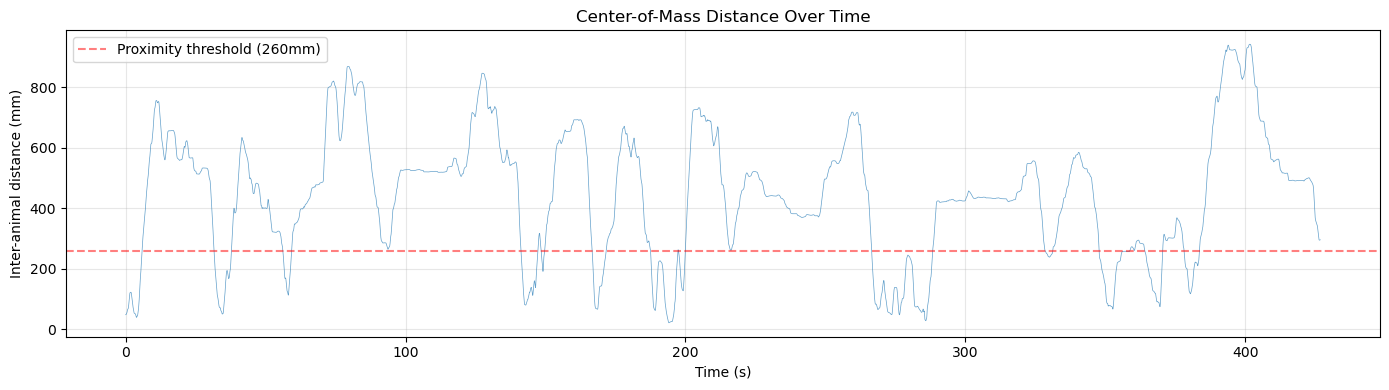


Proximity events (<260.0mm): 2599 frames
Percentage in proximity: 20.5%


In [6]:
# Compute center-of-mass distance between animals
dist = compute_com_distance(
    merged,
    p1="com1",
    p2="com2",
    smooth_window=5,  # Smooth positions
    dist_smooth_window=3  # Smooth distance
)

print("Distance statistics (mm):")
print(dist.describe())

# Plot distance over time
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dist.index / 1000, dist.values, linewidth=0.5, alpha=0.7)
ax.axhline(y=260, color='r', linestyle='--', label='Proximity threshold (260mm)', alpha=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Inter-animal distance (mm)')
ax.set_title('Center-of-Mass Distance Over Time')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Identify proximity events
proximity_threshold = 260.0  # mm
proximity_frames = get_proximity_rows_by_com(
    merged,
    threshold_mm=proximity_threshold,
    smooth_window=5
)

print(f"\nProximity events (<{proximity_threshold}mm): {len(proximity_frames)} frames")
print(f"Percentage in proximity: {len(proximity_frames)/len(merged)*100:.1f}%")

---
## 3. Motion & Velocity Analysis

Compute velocity vectors, speeds, and movement directions for both animals.

In [7]:
# Compute motion characteristics for both animals
motion_animal1 = compute_motion_direction(
    merged,
    prefix="com1",
    time_col="timestamp_ms_mini",
    pos_smooth=5,
    vel_smooth=5
)

motion_animal2 = compute_motion_direction(
    merged,
    prefix="com2",
    time_col="timestamp_ms_mini",
    pos_smooth=5,
    vel_smooth=5
)

print("Motion analysis complete")
print(f"Velocity units: {motion_animal1.attrs.get('velocity_units', 'unknown')}")
print(f"\nAnimal 1 speed statistics (mm/s):")
print(motion_animal1['com1_speed'].describe())
print(f"\nAnimal 2 speed statistics (mm/s):")
print(motion_animal2['com2_speed'].describe())

Motion analysis complete
Velocity units: mm/frame

Animal 1 speed statistics (mm/s):
count    12700.000000
mean         1.686132
std          2.127642
min          0.000000
25%          0.073378
50%          0.538677
75%          2.873735
max          9.612979
Name: com1_speed, dtype: float64

Animal 2 speed statistics (mm/s):
count    12700.000000
mean         0.912863
std          1.409521
min          0.000000
25%          0.041946
50%          0.166751
75%          1.222840
max          7.232311
Name: com2_speed, dtype: float64


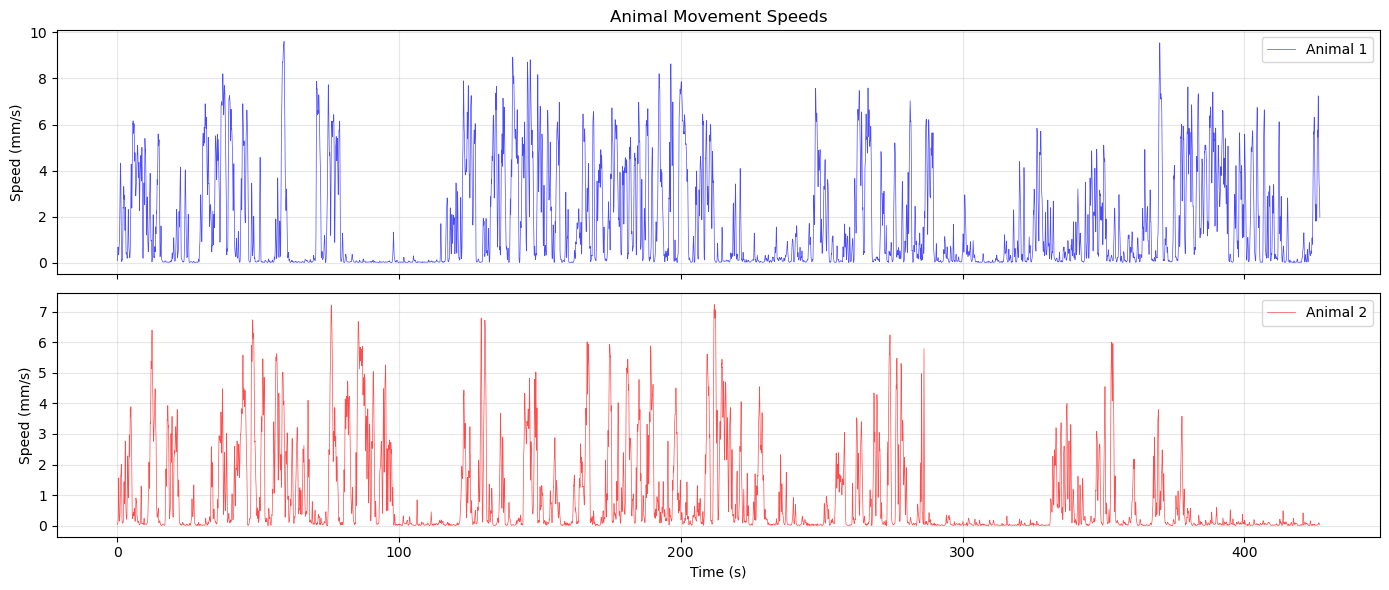

In [8]:
# Plot speed comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Animal 1
axes[0].plot(motion_animal1.index / 1000, motion_animal1['com1_speed'], 
             linewidth=0.5, alpha=0.7, color='blue', label='Animal 1')
axes[0].set_ylabel('Speed (mm/s)')
axes[0].set_title('Animal Movement Speeds')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Animal 2
axes[1].plot(motion_animal2.index / 1000, motion_animal2['com2_speed'],
             linewidth=0.5, alpha=0.7, color='red', label='Animal 2')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Speed (mm/s)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 4. Approach Detection

Detect approach behaviors where animals move toward each other with sufficient speed.

In [9]:
# Detect approach events
approach_results = detect_approaches(
    merged,
    p1="com1",
    p2="com2",
    time_col="timestamp_ms_mini",
    pos_smooth=5,
    vel_smooth=5,
    radial_thresh=20.0,    # mm/s toward the other animal
    speed_min=5.0,         # mm/s minimum speed
    dist_min=None,         # No minimum (include close encounters)
    dist_max=300.0,        # Only consider within 300mm
    min_samples=15,        # Minimum 15 frames (~0.5s at 30fps)
    return_intervals=True
)

frames = approach_results['frames']
intervals = approach_results['intervals']

print("Approach Detection Summary")
print("="*50)
print(f"Animal 1 approaches: {len(intervals['approach1'])} events")
print(f"Animal 2 approaches: {len(intervals['approach2'])} events")
print(f"Mutual approaches: {len(intervals['mutual'])} events")
print(f"\nTotal frames with approach behavior: {frames[['approach1', 'approach2', 'mutual']].any(axis=1).sum()}")

Approach Detection Summary
Animal 1 approaches: 0 events
Animal 2 approaches: 0 events
Mutual approaches: 0 events

Total frames with approach behavior: 0


In [10]:
# Display first few approach intervals
if len(intervals['mutual']) > 0:
    print("\nFirst 3 mutual approach events:")
    for i, event in enumerate(intervals['mutual'][:3], 1):
        print(f"\nEvent {i}:")
        print(f"  Start: {event['start_time_s']:.2f}s (frame {event['start_idx']})")
        print(f"  Duration: {event['duration_s']:.2f}s")
        print(f"  Min distance: {event['min_dist_mm']:.1f}mm")
        print(f"  Median distance: {event['median_dist_mm']:.1f}mm")

---
## 5. Keypoint-Level Analysis

Analyze distances between specific body parts (e.g., snout-to-tail proximity).

In [11]:
# Compute snout-to-body-part distances during proximity
snout_distances = snout_to(
    merged,
    others=("Snout", "Tail(base)", "SpineM"),
    rows=proximity_frames,
    a1="a1",
    a2="a2"
)

print("Snout-to-body-part distances during proximity events:")
print(snout_distances.describe())

Snout-to-body-part distances during proximity events:
       snout_a1__to__snout_a2_mm  snout_a1__to__tailbase_a2_mm  snout_a1__to__spinem_a2_mm
count                2599.000000                   2599.000000                 2599.000000
mean                  155.581758                    147.208223                  146.618237
std                    86.807793                     93.455392                   88.555064
min                     0.914267                      6.027832                   13.437517
25%                    85.253738                     58.534903                   60.699917
50%                   147.472845                    136.869181                  146.350792
75%                   219.336040                    227.999885                  223.688825
max                   372.425787                    357.619118                  331.181228


---
## 6. Skeleton Visualization

Visualize 2D skeleton poses for key interaction moments.

Visualizing 12 frames


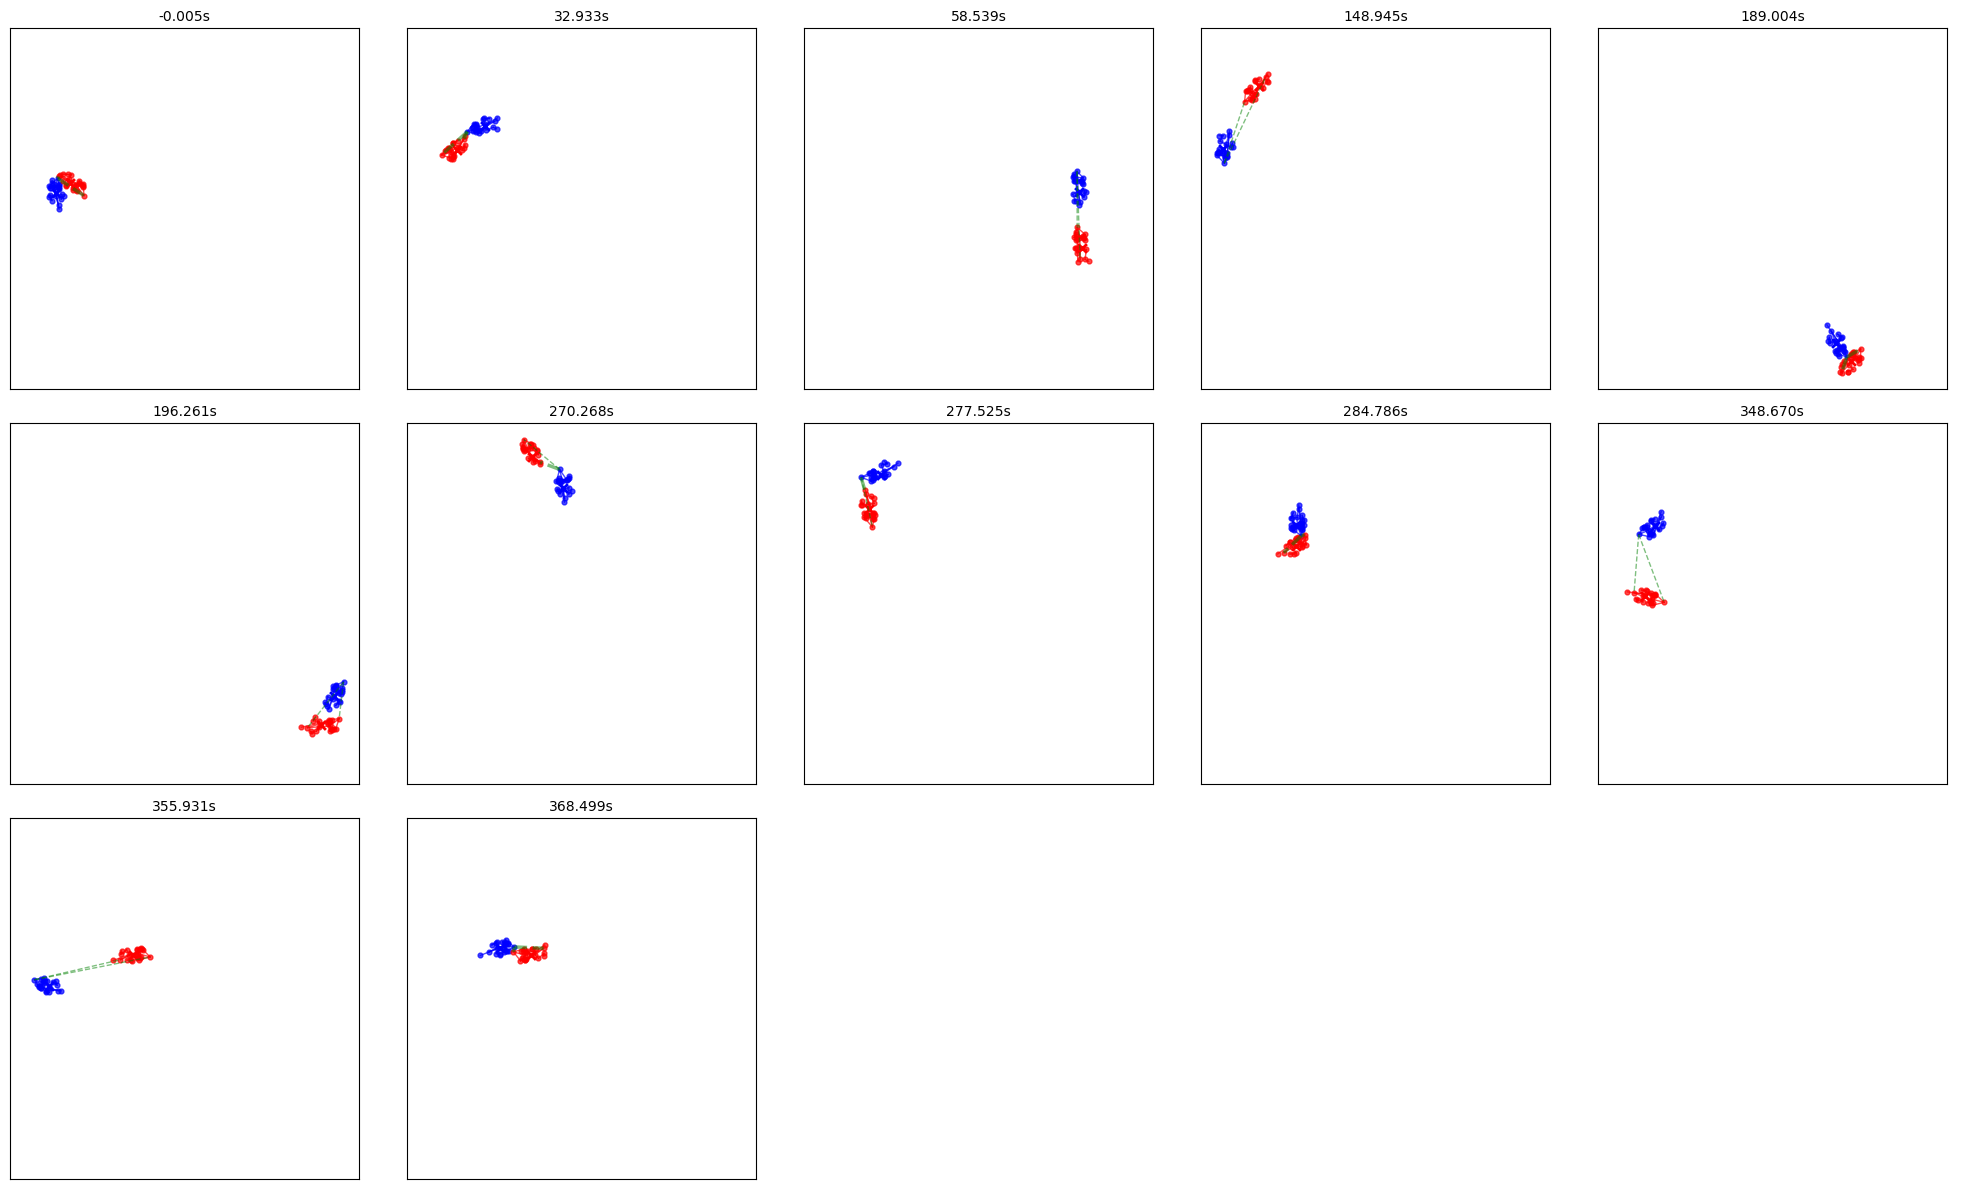

In [12]:
# Select frames to visualize from mutual approach events
if len(intervals['mutual']) > 0:
    first_mutual = intervals['mutual'][0]
    start_idx = first_mutual['start_idx']
    end_idx = first_mutual['end_idx_exclusive']
    viz_frames = merged.index[start_idx:end_idx:max(1, (end_idx-start_idx)//12)]
else:
    # Fall back to random proximity frames
    viz_frames = proximity_frames[::len(proximity_frames)//12][:12]

print(f"Visualizing {len(viz_frames)} frames")

# Plot skeletons
plot_skeleton_frames(
    merged,
    rows=viz_frames,
    n=12,
    animal1="a1",
    animal2="a2",
    pairs=(("Snout", "Snout"), ("Snout", "Tail(base)")),
    threshold_mm=100,
    invert_y=False
)
plt.show()

---
## 7. Summary Statistics

In [13]:
# Compile summary statistics
total_time_s = (merged.index.max() - merged.index.min()) / 1000

summary = {
    "Recording duration": f"{total_time_s:.1f}s ({total_time_s/60:.1f}min)",
    "Total frames": len(merged),
    "Frames in proximity": f"{len(proximity_frames)} ({len(proximity_frames)/len(merged)*100:.1f}%)",
    "Mean distance": f"{dist.mean():.1f}mm",
    "Min distance": f"{dist.min():.1f}mm",
    "Approach events (A1)": len(intervals['approach1']),
    "Approach events (A2)": len(intervals['approach2']),
    "Mutual approaches": len(intervals['mutual']),
    "Mean speed A1": f"{motion_animal1['com1_speed'].mean():.1f}mm/s",
    "Mean speed A2": f"{motion_animal2['com2_speed'].mean():.1f}mm/s",
}

print("\n" + "="*60)
print("SESSION SUMMARY")
print("="*60)
for key, value in summary.items():
    print(f"{key:.<40} {value}")
print("="*60)


SESSION SUMMARY
Recording duration...................... 426.8s (7.1min)
Total frames............................ 12700
Frames in proximity..................... 2599 (20.5%)
Mean distance........................... 445.0mm
Min distance............................ 21.4mm
Approach events (A1).................... 0
Approach events (A2).................... 0
Mutual approaches....................... 0
Mean speed A1........................... 1.7mm/s
Mean speed A2........................... 0.9mm/s


---
## Notes

### Analysis Parameters
- Position smoothing: 5-frame window
- Velocity smoothing: 5-frame window  
- Proximity threshold: 260mm
- Approach radial velocity: ≥20mm/s
- Minimum speed: ≥5mm/s
- Minimum event duration: 15 frames

### Next Steps
1. Correlate approach events with calcium imaging activity
2. Analyze specific body part interactions
3. Classify interaction types based on posture
4. Generate video overlays
5. Compare across sessions